In [1]:
import os
import glob
import xarray as xr
import rioxarray
import numpy as np
import random
import pandas as pd
import geopandas as gpd
from rasterstats import zonal_stats
import rasterstats
import matplotlib.pyplot as plt
%matplotlib inline
import datetime
import rasterio
from rasterio.mask import mask
import seaborn as sns
from shapely.geometry import box
from rasterio.enums import Resampling
import time
import gc
from scipy.stats import linregress

In [2]:
# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "rel"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

In [3]:
# --- 1. Fix the Automatic Band List (Ignore previous results) ---
main_folder = 'F://ETc'

In [4]:
# Use your first successful etc_da or your LULC map to get the bounds
# This ensures even small-AOI dates stay in the correct 'place' on the page.
first_date_path = 'F://ETc/2023-07-14/ETc_2023-07-14.tif'
master_etc = rioxarray.open_rasterio(first_date_path)
global_x_lims = (float(master_etc.x.min()), float(master_etc.x.max()))
global_y_lims = (float(master_etc.y.min()), float(master_etc.y.max()))

### Zonal Statistics
Zonal statistical for summarizing the evapotranspiration metrics across the study area governorates.

In [5]:
def extract_governorate_stats_safe(map_path, gdf, metric_name):
    """Memory-safe zonal stats using per-feature cropping"""
    results = []
    
    # Open map with chunks to save memory
    with rioxarray.open_rasterio(map_path, chunks=True) as src:
        # Loop through each governorate individually
        for _, row in gdf.iterrows():
            try:
                # 1. Clip the raster to the individual governorate's bounds
                # This prevents the 31GB allocation error
                clipped = src.rio.clip([row.geometry], gdf.crs, drop=True)
                
                # 2. Run zonal stats on the small clipped piece
                # We use the numpy array directly to be fast
                val = clipped.values.flatten()
                mean_val = val[~pd.isna(val)].mean() if len(val[~pd.isna(val)]) > 0 else None
                
                results.append(mean_val)
            except Exception:
                results.append(None)
    
    return results

In [6]:
# --- New Optimized Implementation ---
gdf_master = gpd.read_file("shapefile/egy_gov.shp")
all_data = []

for date_folder in os.listdir(main_folder):
    sub_path = os.path.join(main_folder, date_folder)
    etc_map = os.path.join(sub_path, f"ETc_{date_folder}.tif")
    wdi_map = os.path.join(sub_path, f"wdi_{date_folder}.tif")
    re_map  = os.path.join(sub_path, f"RE_{date_folder}.tif")

    if not os.path.exists(etc_map): continue

    # Ensure CRS matches only once per loop
    with rioxarray.open_rasterio(etc_map) as tmp:
        gdf_projected = gdf_master.to_crs(tmp.rio.crs)

    # Extract metrics safely
    etc_vals = extract_governorate_stats_safe(etc_map, gdf_projected, "ETc")
    wdi_vals = extract_governorate_stats_safe(wdi_map, gdf_projected, "WDI")
    re_vals  = extract_governorate_stats_safe(re_map, gdf_projected, "RE")

    # Build the date dataframe
    df_date = pd.DataFrame({
        'Governorate': gdf_projected['ADM1_EN'],
        'ETc': etc_vals,
        'WDI': wdi_vals,
        'RE': re_vals,
        'Date': date_folder,
        'Year': date_folder[:4]
    }).dropna(subset=['ETc']) # Keep only Govs covered by the tile

    all_data.append(df_date)
    print(f"✅ Processed zonal stats for: {date_folder}")

# --- Saving the Two Files ---
# 1. The Master File (All 12 dates)
master_df = pd.concat(all_data)

# Calculate Daily Anomaly: How much each Gov deviates from the Delta Mean ON THAT DAY
# This helps identify which regions were hit hardest during specific heatwaves
master_df['Daily_Mean_ETc'] = master_df.groupby('Date')['ETc'].transform('mean')
master_df['Abs_Anomaly'] = master_df['ETc'] - master_df['Daily_Mean_ETc']

master_df.to_csv("Master_Zonal_Stats_All_Dates.csv", index=False)

# 2. The Seasonal Summary (Aggregated)
# We calculate the mean of everything, including our new Anomaly
seasonal_summary = master_df.groupby(['Governorate', 'Year'])[['ETc', 'WDI', 'RE', 'Abs_Anomaly']].mean().reset_index()

# Rename the column for the final table to be clearer
seasonal_summary.rename(columns={'Abs_Anomaly': 'Mean_Seasonal_Anomaly'}, inplace=True)

seasonal_summary.to_csv("Seasonal_Average_Summary.csv", index=False)

print("✅ Analysis Complete. Files saved: Master_Zonal_Stats_All_Dates.csv and Seasonal_Average_Summary.csv")

✅ Processed zonal stats for: 2023-07-14
✅ Processed zonal stats for: 2023-07-22
✅ Processed zonal stats for: 2023-08-07
✅ Processed zonal stats for: 2023-08-31
✅ Processed zonal stats for: 2023-09-08
✅ Processed zonal stats for: 2024-06-14
✅ Processed zonal stats for: 2024-06-22
✅ Processed zonal stats for: 2024-07-08
✅ Processed zonal stats for: 2024-07-24
✅ Processed zonal stats for: 2024-08-01
✅ Processed zonal stats for: 2024-08-17
✅ Processed zonal stats for: 2024-09-02
✅ Analysis Complete. Files saved: Master_Zonal_Stats_All_Dates.csv and Seasonal_Average_Summary.csv


In [5]:
def extract_governorate_stats(map_path, gdf, metric_name):
    """Memory-safe zonal stats using per-feature cropping"""
    means = []
    stds = []
    
    # Open map with chunks to save memory
    with rioxarray.open_rasterio(map_path, chunks=True) as src:
        # Loop through each governorate individually
        for _, row in gdf.iterrows():
            try:
                # 1. Clip the raster to the individual governorate's bounds
                # This prevents the 31GB allocation error
                clipped = src.rio.clip([row.geometry], gdf.crs, drop=True)
                
                # 2. Run zonal stats on the small clipped piece
                # We use the numpy array directly to be fast
                val = clipped.values.flatten()
                mean_val = val[~pd.isna(val)].mean() if len(val[~pd.isna(val)]) > 0 else None
                std_val = val[~pd.isna(val)].std() if len(val[~pd.isna(val)]) > 0 else None
                
                means.append(mean_val)
                stds.append(std_val)
            except Exception:
                means.append(None)
                stds.append(None)
    
    return means, stds

In [6]:
# --- New Optimized Implementation ---
gdf_master = gpd.read_file("shapefile/egy_gov.shp")
all_data = []

for date_folder in os.listdir(main_folder):
    sub_path = os.path.join(main_folder, date_folder)
    tvdi_map = os.path.join(sub_path, f"tvdi_{date_folder}.tif")
    etc_map = os.path.join(sub_path, f"ETc_{date_folder}.tif")
    wdi_map = os.path.join(sub_path, f"wdi_{date_folder}.tif")
    re_map  = os.path.join(sub_path, f"RE_{date_folder}.tif")

    if not os.path.exists(etc_map): continue

    # Ensure CRS matches only once per loop
    with rioxarray.open_rasterio(etc_map) as tmp:
        gdf_projected = gdf_master.to_crs(tmp.rio.crs)

    # Extract metrics safely
    tvdi_vals, _ = extract_governorate_stats(tvdi_map, gdf_projected, "TVDI")
    etc_vals, etc_std = extract_governorate_stats(etc_map, gdf_projected, "ETc")
    wdi_vals, _ = extract_governorate_stats(wdi_map, gdf_projected, "WDI")
    re_vals, _  = extract_governorate_stats(re_map, gdf_projected, "RE")

    # Build the date dataframe
    df_date = pd.DataFrame({
        'Governorate': gdf_projected['ADM1_EN'],
        'TVDI': tvdi_vals,
        'ETc': etc_vals,
        'WDI': wdi_vals,
        'ETc_std': etc_std,
        'RE': re_vals,
        'Date': date_folder,
        'Year': date_folder[:4]
    }).dropna(subset=['ETc']) # Keep only Govs covered by the tile

    # Calculate CV (%)
    df_date['CV_ETc'] = (df_date['ETc_std'] / df_date['ETc']) * 100

    all_data.append(df_date)
    print(f"✅ Processed zonal stats for: {date_folder}")

# --- Saving the Two Files ---
# 1. The Master File (All 12 dates)
master_df = pd.concat(all_data)

# Calculate Daily Anomaly: How much each Gov deviates from the Delta Mean ON THAT DAY
# This helps identify which regions were hit hardest during specific heatwaves
master_df['Daily_Mean_ETc'] = master_df.groupby('Date')['ETc'].transform('mean')
master_df['Abs_Anomaly'] = master_df['ETc'] - master_df['Daily_Mean_ETc']

master_df.to_csv("Master_Zonal_Stats_All_Dates2.csv", index=False)

# 2. The Seasonal Summary (Aggregated)
# We calculate the mean of everything, including our new Anomaly
seasonal_summary = master_df.groupby(['Governorate', 'Year'])[['ETc', 'TVDI', 'WDI', 'RE', 'CV_ETc', 'Abs_Anomaly']].mean().reset_index()

# Rename the column for the final table to be clearer
seasonal_summary.rename(columns={'Abs_Anomaly': 'Mean_Seasonal_Anomaly'}, inplace=True)

seasonal_summary.to_csv("Seasonal_Average_Summary2.csv", index=False)

print("✅ Analysis Complete. Files saved: Master_Zonal_Stats_All_Dates.csv and Seasonal_Average_Summary.csv")

✅ Processed zonal stats for: 2023-07-14
✅ Processed zonal stats for: 2023-07-22
✅ Processed zonal stats for: 2023-08-07
✅ Processed zonal stats for: 2023-08-31
✅ Processed zonal stats for: 2023-09-08
✅ Processed zonal stats for: 2024-06-14
✅ Processed zonal stats for: 2024-06-22
✅ Processed zonal stats for: 2024-07-08
✅ Processed zonal stats for: 2024-07-24
✅ Processed zonal stats for: 2024-08-01
✅ Processed zonal stats for: 2024-08-17
✅ Processed zonal stats for: 2024-09-02
✅ Analysis Complete. Files saved: Master_Zonal_Stats_All_Dates.csv and Seasonal_Average_Summary.csv


In [23]:
def plot_governorate_timeseries_clean(master_df, metric='WDI'):
    plt.figure(figsize=(16, 8))
    
    # 1. Sort the actual dates so the order is correct
    master_df['Date'] = pd.to_datetime(master_df['Date'])
    plot_df = master_df.sort_values('Date').copy()
    
    # 2. Convert to string for the X-axis
    plot_df['Date_Str'] = plot_df['Date'].dt.strftime('%Y-%m-%d')

    # 3. CRITICAL: Use 'sort=False' in lineplot and pass the categorical strings
    # This tells Seaborn: "Don't try to build a timeline, just plot these 12 labels in order"
    sns.lineplot(data=plot_df, x='Date_Str', y=metric, hue='Governorate', 
                 marker='o', markersize=10, linewidth=3, sort=False)

    plt.title(f"Temporal Trend of {metric} by Governorate", 
              fontsize=20, fontweight='bold', pad=20)
    plt.ylabel(f"Mean {metric}", fontsize=20, fontweight='bold', labelpad=15)
    plt.xlabel("Observation Date", fontsize=20, fontweight='bold', labelpad=15)
    
    # Add a vertical dashed line to separate the two years
    # This helps the reader see where the 2023-2024 jump happens
    unique_dates = plot_df['Date_Str'].unique()
    # Find where 2024 starts
    start_2024 = next((i for i, date in enumerate(unique_dates) if '2024' in date), None)
    if start_2024:
        plt.axvline(x=start_2024 - 0.5, color='black', linestyle='--', alpha=0.5)
        #plt.text(start_2024 - 0.4, plt.ylim()[1]*0.9, '2024 Season', fontsize=20, fontweight='bold')

    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=20)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.xticks(rotation=45, fontsize=18)
    plt.yticks(fontsize=18)
    
    plt.tight_layout()
    plt.savefig(f"Gov_TimeSeries_Clean_{metric}.png", dpi=300)
    plt.show()

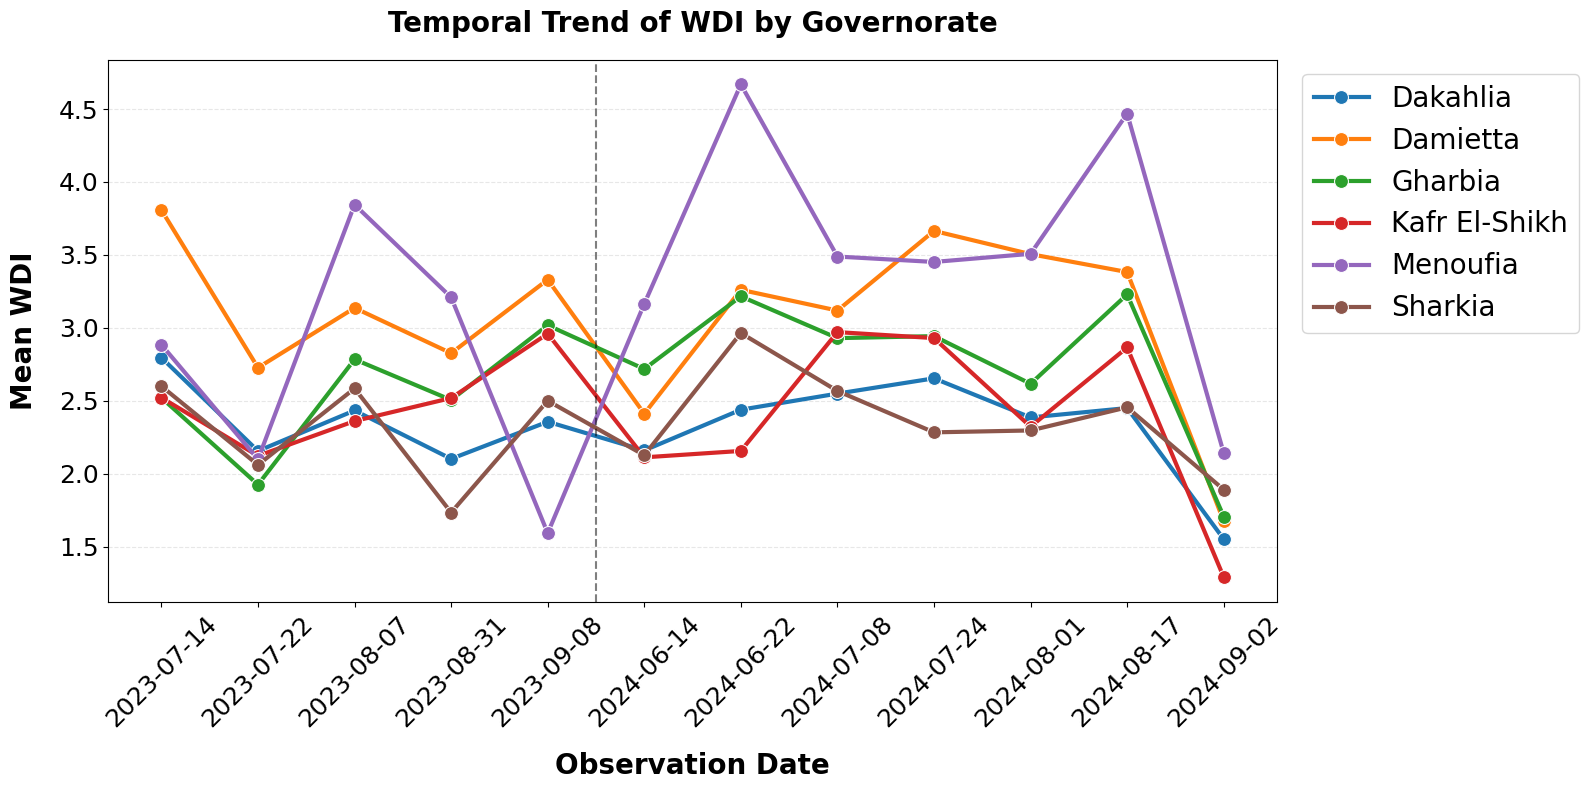

In [24]:
# Run for WDI (Stress Trend)
plot_governorate_timeseries_clean(master_df, metric='WDI')

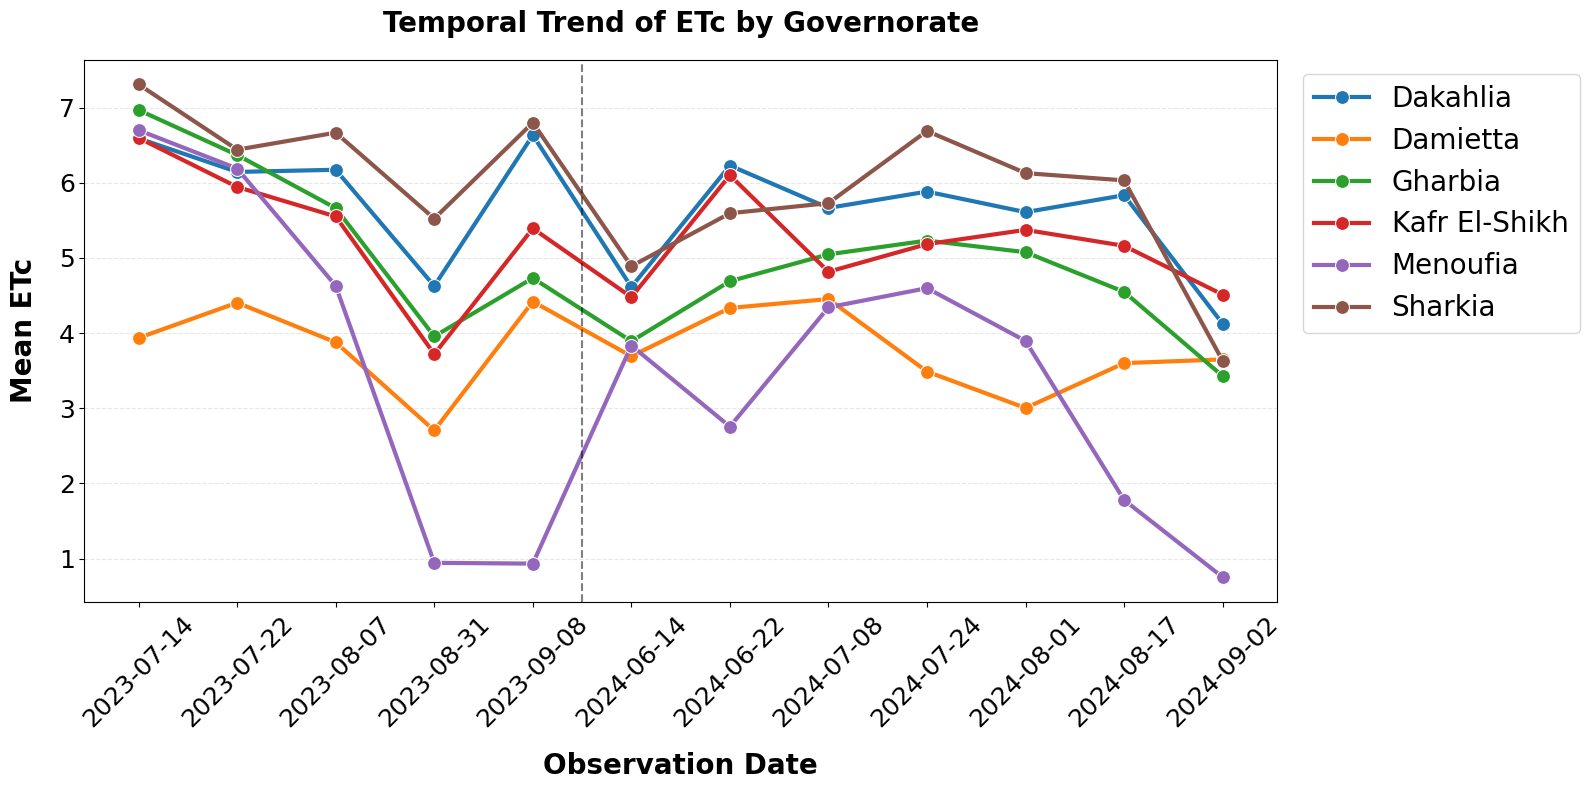

In [25]:
# Run for ETc (Water Use Trend)
plot_governorate_timeseries_clean(master_df, metric='ETc')

In [28]:
def plot_seasonal_etc_comparison(seasonal_summary):
    plt.figure(figsize=(14, 8))
    
    # Sort the dataframe by ETc so the bars look organized
    df_sorted = seasonal_summary.sort_values('ETc', ascending=False)
    
    # Create the grouped bar chart
    ax = sns.barplot(data=df_sorted, x='Governorate', y='ETc', hue='Year', palette='viridis')
    
    # Formatting
    plt.title("Seasonal Mean ETc Comparison: 2023 vs 2024", fontsize=20, fontweight='bold', pad=20)
    plt.ylabel("Mean ETc (mm/day)", fontsize=20, fontweight='bold', labelpad=15)
    plt.xlabel("Governorate", fontsize=20, fontweight='bold', labelpad=15)
    
    plt.xticks(rotation=45, fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(title='Year', fontsize=20, title_fontsize=20)
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("Comparison_ETc_2023_2024.png", dpi=300)
    plt.show()

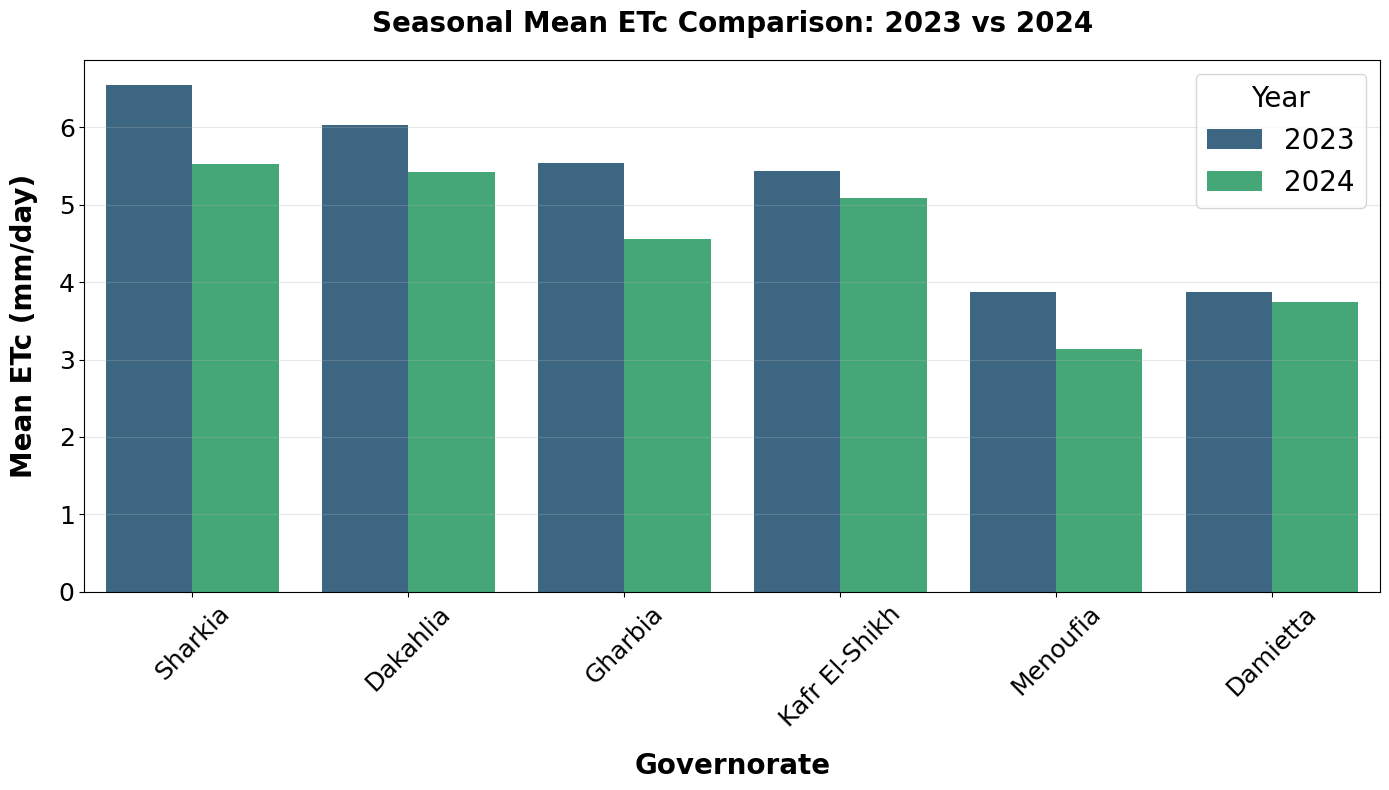

In [29]:
plot_seasonal_etc_comparison(seasonal_summary)

In [65]:
def plot_diverging_anomaly(seasonal_summary):
    # We will plot 2023 as it is your most recent/robust year
    # Or average both years. Here we use 2023.
    df_2023 = seasonal_summary[seasonal_summary['Year'] == '2023'].sort_values('Mean_Seasonal_Anomaly')
    
    plt.figure(figsize=(12, 10))
    
    # REDUCE HEIGHT: Change (12, 10) to (12, 6) or (12, 5) depending on the number of Govs
    num_govs = len(df_2023)
    plt.figure(figsize=(12, num_govs * 0.8)) # Dynamic height: ~0.8 inches per governorate
    
    # Create colors: Green for positive, Red for negative
    colors = ['#2ca02c' if x > 0 else '#d62728' for x in df_2023['Mean_Seasonal_Anomaly']]
    
    # Horizontal bar chart
    plt.hlines(y=df_2023['Governorate'], xmin=0, xmax=df_2023['Mean_Seasonal_Anomaly'], color=colors, alpha=0.8, linewidth=5)
    plt.plot(df_2023['Mean_Seasonal_Anomaly'], df_2023['Governorate'], "o", color='black', markersize=10)
    
    # Add the vertical zero line
    plt.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    # Formatting
    plt.title("Regional ETc Performance Anomaly (2023)", fontsize=20, fontweight='bold', pad=20)
    plt.xlabel("Deviation from Delta Mean (mm/day)", fontsize=20, fontweight='bold', labelpad=15)
    plt.ylabel("Governorate", fontsize=20, fontweight='bold', labelpad=15)
    
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    
    # Adding text labels on the bars for clarity
    for i, val in enumerate(df_2023['Mean_Seasonal_Anomaly']):
        plt.text(x=val, 
                 y=i + 0.05, # Increase y slightly to move text ABOVE the line
                 s=f'{val:+.2f}', # The '+' sign shows +0.5 or -0.5 clearly
                 va='bottom', 
                 ha='center', # Centers the text over the dot
                 fontsize=18, 
                 fontweight='bold',
                 color='darkgreen' if val > 0 else 'darkred')

    # Tighten the Y-limits to remove empty space at top/bottom
    plt.ylim(-0.7, num_govs - 0.3)
    
    plt.tight_layout()
    plt.savefig("Diverging_Anomaly_2023.png", dpi=300)
    plt.show()

<Figure size 1200x1000 with 0 Axes>

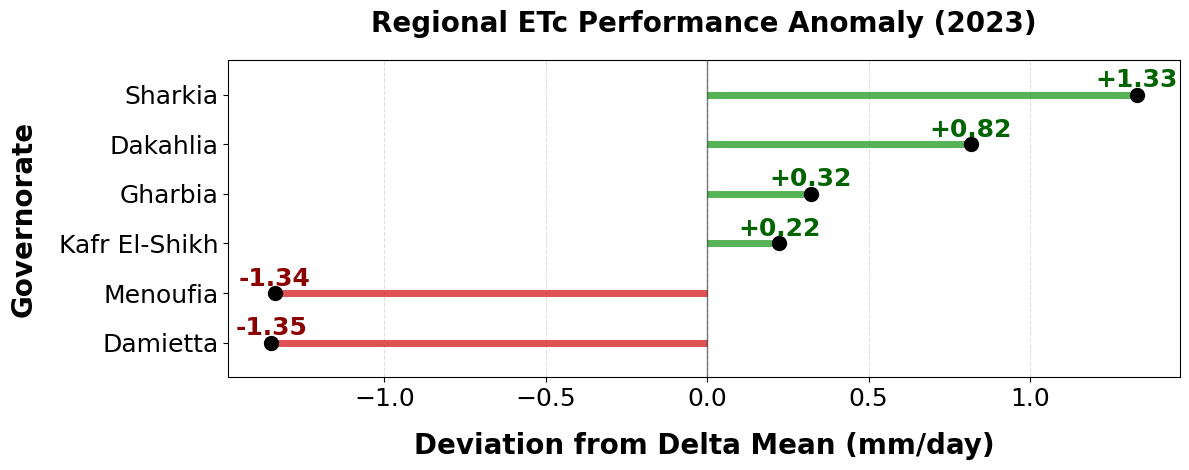

In [66]:
plot_diverging_anomaly(seasonal_summary)

In [64]:
def plot_diverging_anomaly(seasonal_summary):
    # We will plot 2024 as it is your most recent/robust year
    # Or average both years. Here we use 2024.
    df_2024 = seasonal_summary[seasonal_summary['Year'] == '2024'].sort_values('Mean_Seasonal_Anomaly')
    
    plt.figure(figsize=(12, 10))
    
    # REDUCE HEIGHT: Change (12, 10) to (12, 6) or (12, 5) depending on the number of Govs
    num_govs = len(df_2024)
    plt.figure(figsize=(12, num_govs * 0.8)) # Dynamic height: ~0.8 inches per governorate
    
    # Create colors: Green for positive, Red for negative
    colors = ['#2ca02c' if x > 0 else '#d62728' for x in df_2024['Mean_Seasonal_Anomaly']]
    
    # Horizontal bar chart
    plt.hlines(y=df_2024['Governorate'], xmin=0, xmax=df_2024['Mean_Seasonal_Anomaly'], color=colors, alpha=0.8, linewidth=5)
    plt.plot(df_2024['Mean_Seasonal_Anomaly'], df_2024['Governorate'], "o", color='black', markersize=10)
    
    # Add the vertical zero line
    plt.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    # Formatting
    plt.title("Regional ETc Performance Anomaly (2024)", fontsize=20, fontweight='bold', pad=20)
    plt.xlabel("Deviation from Delta Mean (mm/day)", fontsize=20, fontweight='bold', labelpad=15)
    plt.ylabel("Governorate", fontsize=20, fontweight='bold', labelpad=15)
    
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    
    # Adding text labels on the bars for clarity
    for i, val in enumerate(df_2024['Mean_Seasonal_Anomaly']):
        plt.text(x=val, 
                 y=i + 0.05, # Increase y slightly to move text ABOVE the line
                 s=f'{val:+.2f}', # The '+' sign shows +0.5 or -0.5 clearly
                 va='bottom', 
                 ha='center', # Centers the text over the dot
                 fontsize=18, 
                 fontweight='bold',
                 color='darkgreen' if val > 0 else 'darkred')

    # Tighten the Y-limits to remove empty space at top/bottom
    plt.ylim(-0.7, num_govs - 0.3)
    
    plt.tight_layout()
    plt.savefig("Diverging_Anomaly_2024.png", dpi=300)
    plt.show()

<Figure size 1200x1000 with 0 Axes>

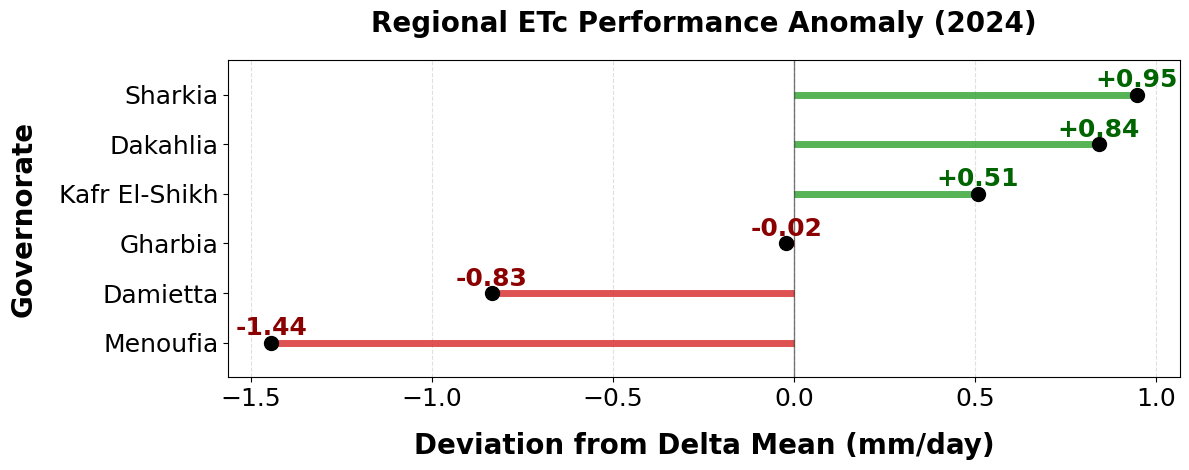

In [62]:
plot_diverging_anomaly(seasonal_summary)

In [79]:
def plot_final_manuscript_stats(seasonal_summary):
    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

    # --- Plot A: Seasonal ETc Comparison ---
    df_sorted = seasonal_summary.sort_values('ETc', ascending=False)
    sns.barplot(data=df_sorted, x='Governorate', y='ETc', hue='Year', palette='viridis', ax=ax1)
    ax1.set_title("A) Seasonal Mean ETc Comparison", fontsize=22, fontweight='bold')
    ax1.tick_params(axis='x', rotation=20, labelsize=18)
    ax1.tick_params(axis='y', labelsize=18)
    ax1.set_ylabel("Mean ETc (mm/day)", fontsize=20)
    ax1.set_xlabel("Governorate", fontsize=20)
    ax1.legend(title='Year', fontsize=20, title_fontsize=20)

    # --- Plot B: Diverging Anomaly 2024 ---
    df_2024 = seasonal_summary[seasonal_summary['Year'] == '2024'].sort_values('Mean_Seasonal_Anomaly')
    colors = ['#2ca02c' if x > 0 else '#d62728' for x in df_2024['Mean_Seasonal_Anomaly']]
    ax2.hlines(y=df_2024['Governorate'], xmin=0, xmax=df_2024['Mean_Seasonal_Anomaly'], color=colors, linewidth=5)
    ax2.axvline(0, color='black', linewidth=1)
    ax2.tick_params(axis='x', labelsize=18)
    ax2.tick_params(axis='y', labelsize=18)
    ax2.set_title("B) Regional Performance Anomaly (2024)", fontsize=22, fontweight='bold')
    ax2.set_xlabel("Deviation from Delta Mean (mm/day)", fontsize=20)
    ax2.set_ylabel("Governorate", fontsize=20)

    plt.tight_layout()
    plt.savefig("Figure5_Zonal_Statistics_Combined.png", dpi=300)
    plt.show()

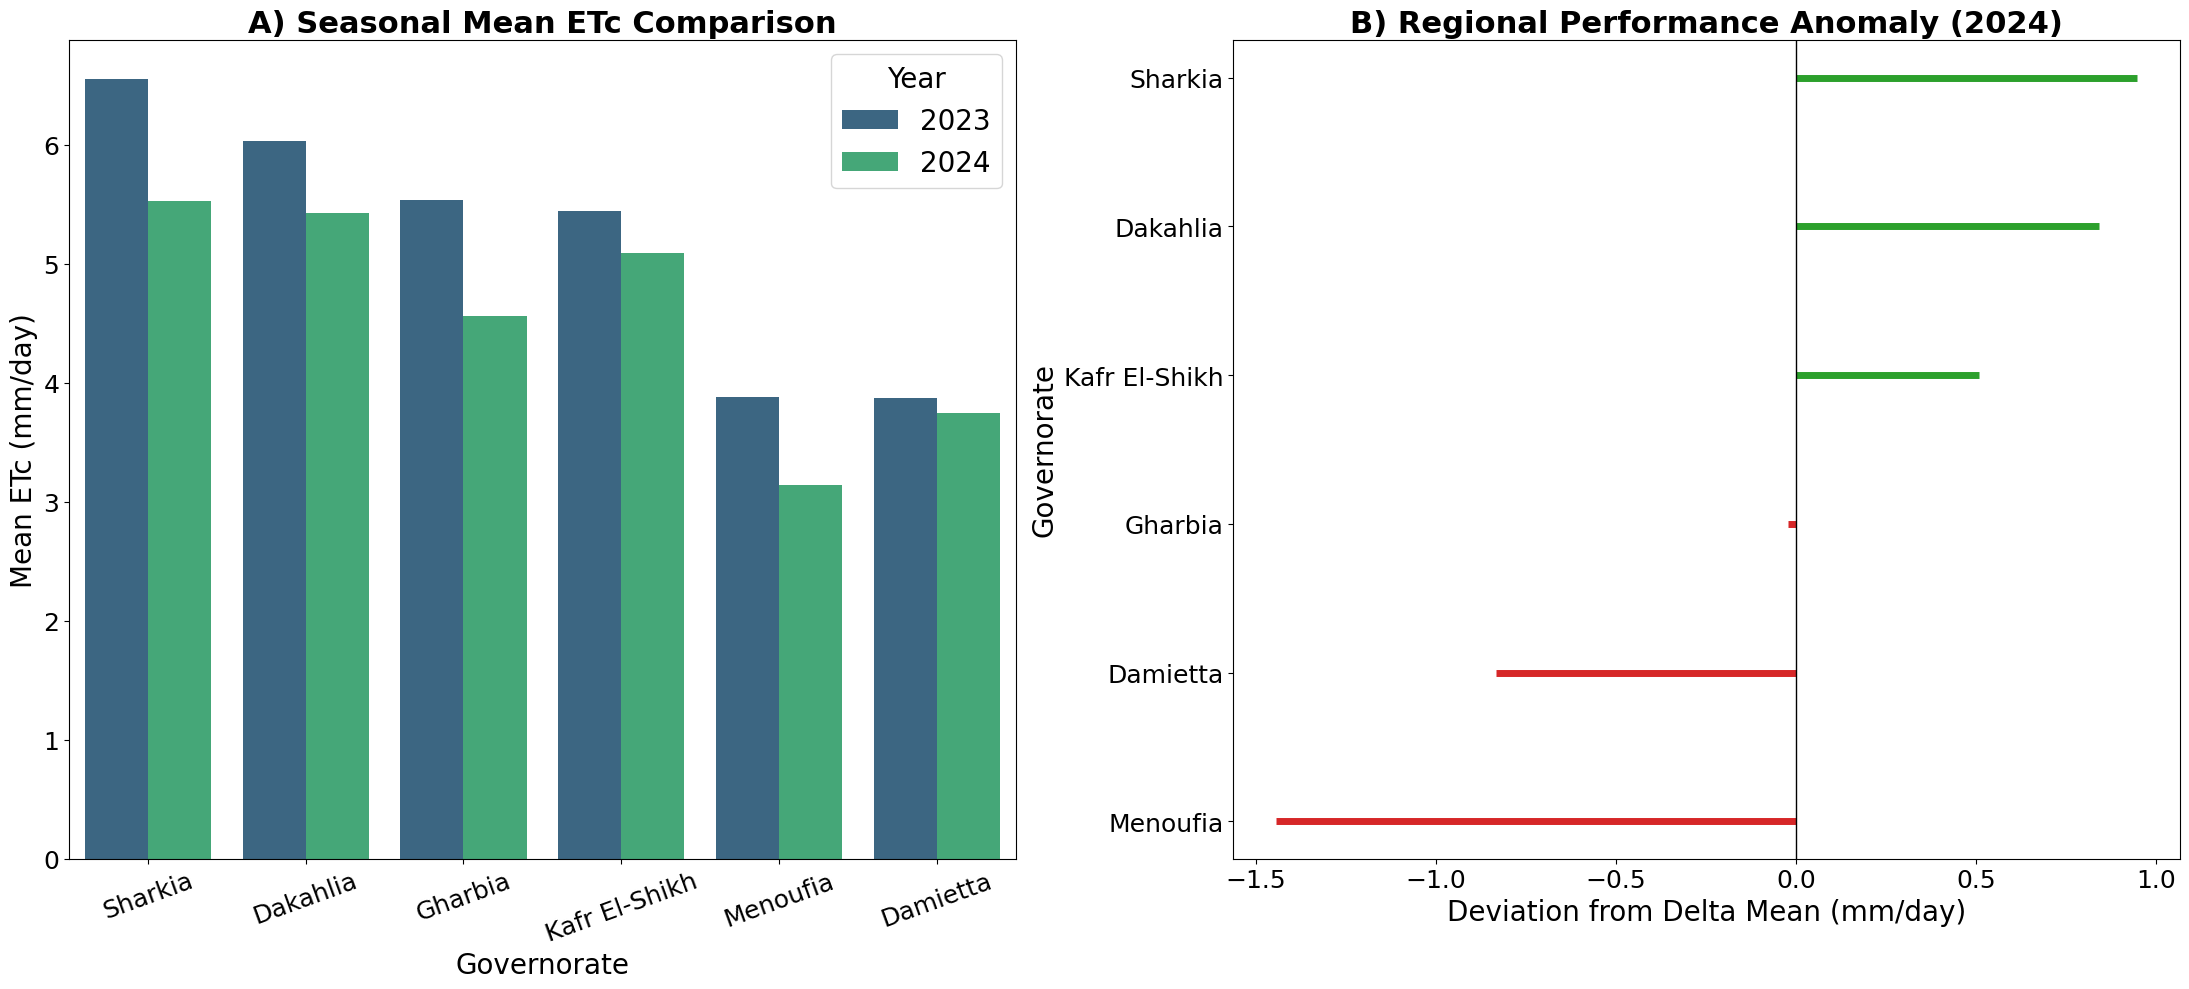

In [80]:
plot_final_manuscript_stats(seasonal_summary)

In [28]:
def plot_final_manuscript_stats3(seasonal_summary):
    # Define the Master Order based ONLY on 2024 performance
    seasonal_summary['Year'] = seasonal_summary['Year'].astype(str)
    df_2024_order = seasonal_summary[seasonal_summary['Year'] == '2024'].sort_values('Mean_Seasonal_Anomaly')
    master_order = df_2024_order['Governorate'].tolist()
    
    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 10))

    # --- Plot A: Seasonal ETc Comparison ---
    df_sorted = seasonal_summary.sort_values('ETc', ascending=False)
    sns.barplot(data=df_sorted, x='Governorate', y='ETc', hue='Year', palette='viridis', ax=ax1)
    ax1.set_title("A) Seasonal Mean ETa Comparison", fontsize=22, fontweight='bold')
    ax1.tick_params(axis='x', rotation=20, labelsize=18)
    ax1.tick_params(axis='y', labelsize=18)
    ax1.set_ylabel("Mean ETa (mm/day)", fontsize=20)
    ax1.set_xlabel("Governorate", fontsize=20)
    ax1.legend(title='Year', fontsize=20, title_fontsize=20)

    # --- Plot B: Diverging Anomaly 2023 ---
    df_2023 = seasonal_summary[seasonal_summary['Year'] == '2023'].set_index('Governorate').reindex(master_order).reset_index()
    colors = ['#2ca02c' if x > 0 else '#d62728' for x in df_2023['Mean_Seasonal_Anomaly']]
    ax2.hlines(y=df_2023['Governorate'], xmin=0, xmax=df_2023['Mean_Seasonal_Anomaly'], color=colors, linewidth=5)
    ax2.axvline(0, color='black', linewidth=1)
    ax2.tick_params(axis='x', labelsize=18)
    ax2.tick_params(axis='y', labelsize=18)
    ax2.set_title("B) Regional Performance Anomaly (2023)", fontsize=22, fontweight='bold')
    ax2.set_xlabel("Deviation from Delta Mean (mm/day)", fontsize=20)
    ax2.set_ylabel("Governorate", fontsize=20)

    # --- Plot C: Diverging Anomaly 2024 ---
    df_2024 = seasonal_summary[seasonal_summary['Year'] == '2024'].sort_values('Mean_Seasonal_Anomaly')
    colors = ['#2ca02c' if x > 0 else '#d62728' for x in df_2024['Mean_Seasonal_Anomaly']]
    ax3.hlines(y=df_2024['Governorate'], xmin=0, xmax=df_2024['Mean_Seasonal_Anomaly'], color=colors, linewidth=5)
    ax3.axvline(0, color='black', linewidth=1)
    ax3.tick_params(axis='x', labelsize=18)
    ax3.tick_params(axis='y', labelsize=18)
    ax3.set_title("C) Regional Performance Anomaly (2024)", fontsize=22, fontweight='bold')
    ax3.set_xlabel("Deviation from Delta Mean (mm/day)", fontsize=20)
    ax3.set_ylabel("Governorate", fontsize=20)

    plt.tight_layout()
    plt.savefig("Figures_Zonal_Statistics_Combined.png", dpi=300)
    plt.show()

In [29]:
# Load the saved data
seasonal_summary = pd.read_csv('Seasonal_Average_Summary2.csv')
seasonal_summary.head()

,Governorate,Year,ETc,TVDI,WDI,RE,CV_ETc,Mean_Seasonal_Anomaly
0,Dakahlia,2023,6.033514,0.349896,2.369140,0.691800,42.336354,0.815483
1,Dakahlia,2024,5.422780,0.387849,2.313321,0.666689,46.528579,0.842201
2,Damietta,2023,3.868585,0.399608,3.165848,0.523230,52.758724,-1.349446
3,Damietta,2024,3.746214,0.430769,3.002926,0.535020,49.204445,-0.834365
4,Gharbia,2023,5.537786,0.445490,2.551085,0.648418,48.000952,0.319755


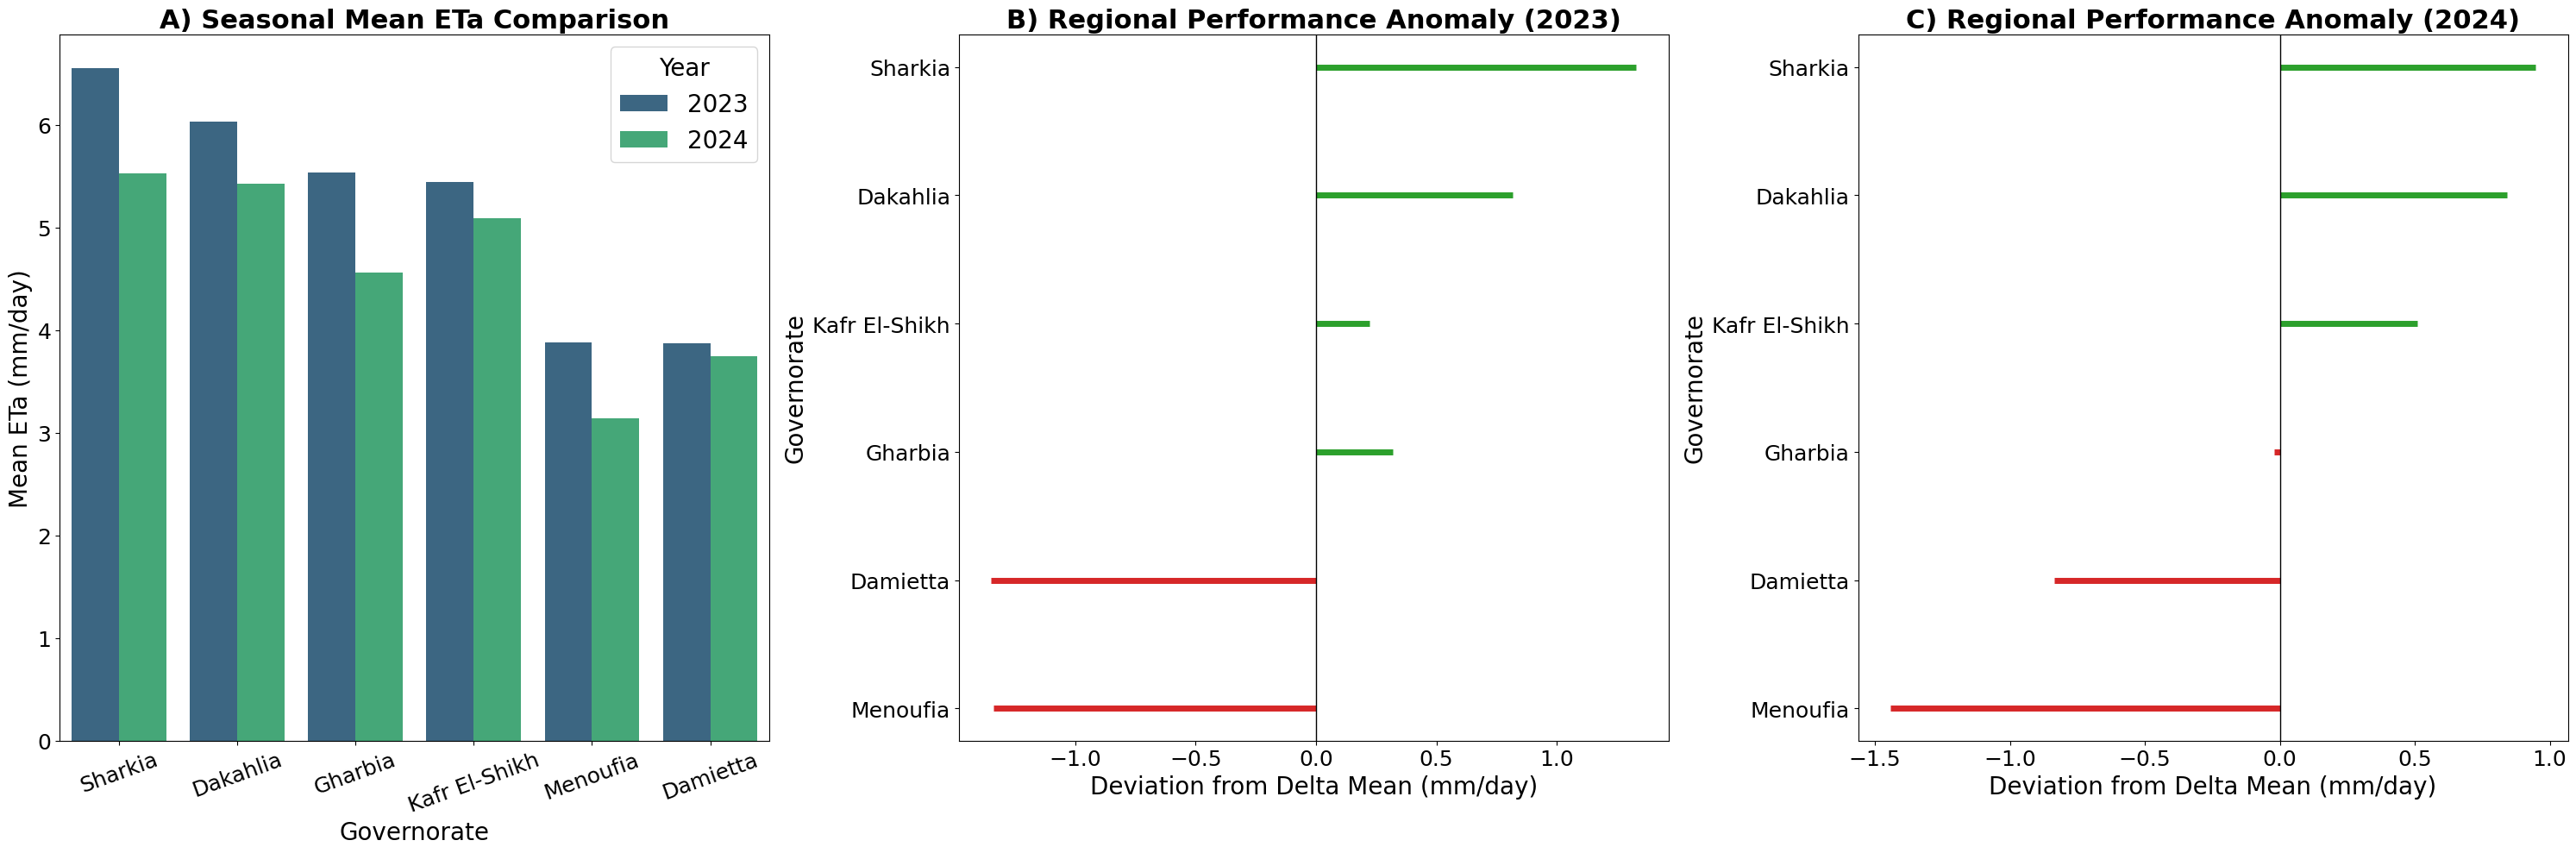

In [30]:
plot_final_manuscript_stats3(seasonal_summary)

### Pearson Correlation Heatmap "Correlation Matrix"

In [5]:
def extract_random_pixel_samples(main_folder, sample_size=100000):
    all_samples = []
    
    # List of the variable names (must match your file naming convention)
    metrics = ['ETc', 'ETp', 'Kcb', 'Ke', 'Ks', 'wdi', 'RE', 'tvdi', 'cwsi', 'ndvi', 'B10', 'ETo', 'RN-MJ', 'TMax', 'TMin', 'RH'] 

    for date_folder in os.listdir(main_folder):
        sub_path = os.path.join(main_folder, date_folder)
        if not os.path.isdir(sub_path): continue
        
        # 1. Find and Open the Master Map (ETc) to use as the grid template
        etc_pattern = os.path.join(sub_path, f"ETc_{date_folder}*.tif")
        etc_files = glob.glob(etc_pattern)
        if not etc_files: continue
        
        master_etc = rioxarray.open_rasterio(etc_files[0], chunks={'x': 2000, 'y': 2000}).squeeze()
        
        date_data = {'ETc': master_etc.values.flatten()}
        
        # 2. Open and Align all other metrics to the Master Map
        for m in metrics:
            if m == 'ETc': continue # Already have it
            
            search_pattern = os.path.join(sub_path, f"{m}_*.tif")
            files = glob.glob(search_pattern)
            
            if files:
                # Open and use reproject_match to force identical pixel counts
                with rioxarray.open_rasterio(files[0], chunks={'x': 2000, 'y': 2000}).squeeze() as src:
                    aligned = src.rio.reproject_match(master_etc)
                    date_data[m] = aligned.values.flatten()
            else:
                print(f"⚠️ Missing {m} for {date_folder}")

        # 3. Safe Sampling
        # Ensure all arrays are the same length (they should be now)
        valid_indices = np.where(~np.isnan(date_data['ETc']))[0]
        
        if len(valid_indices) > sample_size:
            chosen_indices = np.random.choice(valid_indices, sample_size, replace=False)
            
            daily_dict = {m: date_data[m][chosen_indices] for m in date_data if m in date_data}
            daily_df = pd.DataFrame(daily_dict)
            daily_df['Date'] = date_folder
            daily_df['Year'] = date_folder[:4]
            
            all_samples.append(daily_df)
            print(f"✅ Aligned and sampled {date_folder}")
        
        # Explicit memory cleanup
        del date_data, master_etc
        
    if not all_samples: return None
    return pd.concat(all_samples).reset_index(drop=True)

In [6]:
# Run the extraction
pixel_master_df = extract_random_pixel_samples(main_folder)
if pixel_master_df is not None:
    pixel_master_df.to_csv("Pixel_Level_Correlation_Data.csv", index=False)

✅ Aligned and sampled 2023-07-14
✅ Aligned and sampled 2023-07-22
✅ Aligned and sampled 2023-08-07
✅ Aligned and sampled 2023-08-31
✅ Aligned and sampled 2023-09-08
✅ Aligned and sampled 2024-06-14
✅ Aligned and sampled 2024-06-22
✅ Aligned and sampled 2024-07-08
✅ Aligned and sampled 2024-07-24
✅ Aligned and sampled 2024-08-01
✅ Aligned and sampled 2024-08-17
✅ Aligned and sampled 2024-09-02


In [3]:
# Load the saved data
df = pd.read_csv('Pixel_Level_Correlation_Data.csv')
df.head()

,ETc,ETp,Kcb,Ke,Ks,wdi,RE,tvdi,cwsi,ndvi,B10,ETo,RN-MJ,TMax,TMin,RH,Date,Year
0,7.107720,9.536292,1.120268,0.110346,0.720249,2.428572,0.745334,0.208746,0.279751,0.813969,307.787537,7.749214,15.533237,37.396410,24.028389,53.212140,2023-07-14,2023
1,0.703551,4.948534,0.589345,0.097676,0.000000,4.244983,0.142174,0.855126,1.000000,0.367301,316.975189,7.202886,10.675694,41.711624,21.605811,41.087606,2023-07-14,2023
2,1.903506,6.648515,0.669503,0.208000,0.064576,4.745009,0.286305,0.652794,0.935424,0.432370,314.271515,7.576631,11.668377,42.293279,21.158361,39.066657,2023-07-14,2023
3,7.530676,9.594080,1.258531,0.010624,0.783114,2.063404,0.784929,0.292305,0.216886,0.925605,307.599548,7.559423,14.261169,38.375396,23.722437,51.142458,2023-07-14,2023
4,9.839633,10.636580,1.164156,0.081535,0.919827,0.796948,0.925075,0.233283,0.080173,0.842606,307.773865,8.538701,16.231312,42.897518,21.830261,43.403496,2023-07-14,2023


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 18 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   ETc     1200000 non-null  float64
 1   ETp     1199619 non-null  float64
 2   Kcb     1200000 non-null  float64
 3   Ke      1200000 non-null  float64
 4   Ks      1200000 non-null  float64
 5   wdi     1199619 non-null  float64
 6   RE      1199619 non-null  float64
 7   tvdi    1200000 non-null  float64
 8   cwsi    1200000 non-null  float64
 9   ndvi    1200000 non-null  float64
 10  B10     1200000 non-null  float64
 11  ETo     1200000 non-null  float64
 12  RN-MJ   1199990 non-null  float64
 13  TMax    1200000 non-null  float64
 14  TMin    1200000 non-null  float64
 15  RH      1200000 non-null  float64
 16  Date    1200000 non-null  object 
 17  Year    1200000 non-null  int64  
dtypes: float64(16), int64(1), object(1)
memory usage: 164.8+ MB


In [5]:
def plot_final_publication_heatmap(df):
    # 1. Scientific Renaming
    rename_dict = {
        'ETc': '$ET_a$', 'ETp': '$ET_p$', 'Ks': '$K_s$', 'Kcb': '$K_{cb}$', 'Ke': '$K_e$',
        'wdi': '$WDI$', 'RE': '$RE$', 'tvdi': '$TVDI$', 'cwsi': '$CWSI$', 'ndvi': '$NDVI$', 
        'B10': '$LST$', 'ETo': '$ET_o$', 'RN-MJ': '$R_n$', 'TMax': '$T_{max}$', 
        'TMin': '$T_{min}$', 'RH': '$RH$'
    }
    
    plot_df = df.rename(columns=rename_dict)
    numeric_df = plot_df.select_dtypes(include=[np.number])
    corr = numeric_df.corr(method='pearson')

    # --- The Mask & Slice ---
    # We want a true triangle. We drop the first column and last row 
    # so there are no "empty" areas at the tips of the triangle.
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Slice the dataframe and mask to remove the empty "ends"
    # This prevents the "hanging" labels
    mask_trimmed = mask[1:, :-1]
    corr_trimmed = corr.iloc[1:, :-1]

    plt.figure(figsize=(16, 13))
    
    # 2. Plotting
    ax = sns.heatmap(corr_trimmed, 
                mask=mask_trimmed, 
                annot=True, 
                fmt=".2f", 
                cmap='RdBu_r', 
                vmin=-1, vmax=1, 
                center=0,
                square=True, 
                linewidths=1.5,
                cbar_kws={"shrink": .7}, 
                annot_kws={"size": 14, "weight": "bold"})

    # --- Colorbar Font Sizes ---
    cbar = ax.collections[0].colorbar
    cbar.set_label("Pearson Correlation Coefficient ($r$)", fontsize=22, fontweight='bold', labelpad=20)
    cbar.ax.tick_params(labelsize=20)

    # --- Tick and Label Alignment ---
    plt.title("Inter-variable Pearson Correlation Matrix\n(Pixel-level Analysis, $N \\approx 1,200,000$)", 
              fontsize=24, fontweight='bold', pad=35)
    
    # Set tick labels with high visibility
    plt.xticks(rotation=45, ha='right', fontsize=20, fontweight='bold')
    plt.yticks(rotation=0, fontsize=20, fontweight='bold')
    
    # This prevents the X-ticks from wandering too far down
    plt.tight_layout()
    
    plt.savefig("Publication_Correlation_Heatmap_Final.png", dpi=300, bbox_inches='tight')
    plt.show()

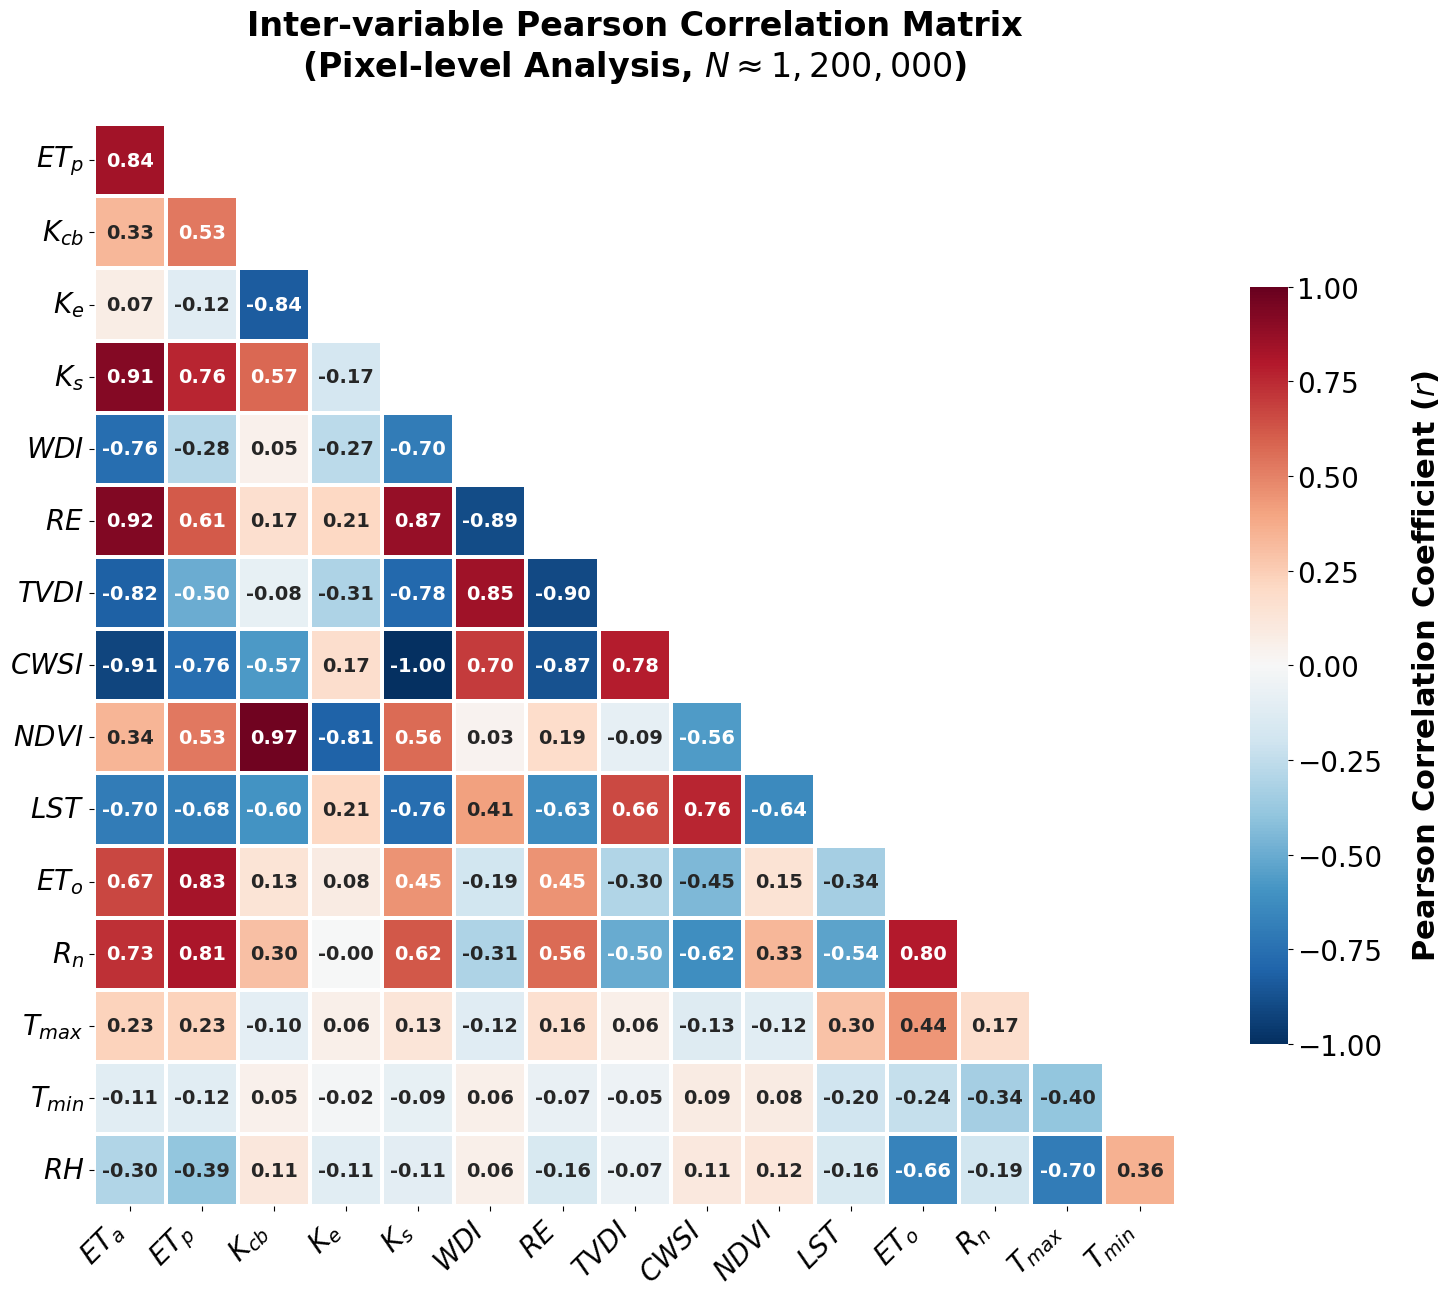

In [10]:
# Run with your pixel-level dataframe
plot_final_publication_heatmap(df.iloc[:, :-2])